<a href="https://colab.research.google.com/github/Sisynn/syesildal-cc2526/blob/main/FinalAssignmentSinemYesildalwitthcsvfile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 53.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.feature_selection import SelectKBest, f_regression

df = pd.read_csv("qm9(2).csv")

# smiles to rdkit molecules
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

descriptor_names = [name for name, _ in Descriptors._descList]

# calculate descriptors
for name in descriptor_names:
    df[name] = df["mol"].apply(
        lambda m: Descriptors.__dict__[name](m) if m is not None else np.nan
    )

# remove rows with missing values
df = df.dropna()


X = df[descriptor_names]
y = df["gap"]

# correlation with band gap
corr = X.corrwith(y).abs().sort_values(ascending=False)
print("top correlated descriptors:")
print(corr.head(10))

# select best descriptors
selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X, y)

selected_descriptors = X.columns[selector.get_support()]
print("selected descriptors:")
print(list(selected_descriptors))


/tmp/ipython-input-2227849041.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["mol"].apply(
/tmp/ipython-input-2227849041.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["mol"].apply(
/tmp/ipython-input-2227849041.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()

top correlated descriptors:
FractionCSP3     0.714814
HallKierAlpha    0.690995
SMR_VSA5         0.577387
VSA_EState2      0.561471
SMR_VSA10        0.537322
Chi1v            0.525361
Chi1n            0.525361
BertzCT          0.520328
BCUT2D_MRHI      0.516771
Chi2v            0.512536
dtype: float64
selected descriptors:
['BCUT2D_MRHI', 'BertzCT', 'Chi1n', 'Chi1v', 'Chi2v', 'HallKierAlpha', 'SMR_VSA10', 'SMR_VSA5', 'VSA_EState2', 'FractionCSP3']


In [4]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

def rdkit_descriptors_from_smiles(smiles):
    # SMILES into RDKit molecule
    mol = Chem.MolFromSmiles(smiles)

    # skip if invalid
    if mol is None:
        return None

    # molecular descriptors for band gap prediction
    return {
        "MolWt": Descriptors.MolWt(mol),           # molecular weight
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),  # non-H atoms
        "NumValenceElectrons": Descriptors.NumValenceElectrons(mol),  # valence electrons
        "NumHDonors": Descriptors.NumHDonors(mol), # H-bond donors
        "NumHAcceptors": Descriptors.NumHAcceptors(mol), # H-bond acceptors
        "TPSA": Descriptors.TPSA(mol),             # polar surface area
        "MolLogP": Descriptors.MolLogP(mol),       # lipophilicity
        "RingCount": Descriptors.RingCount(mol),   # number of rings
        "NumRotatableBonds": Descriptors.NumRotatableBonds(mol), # rotatable bonds
        "FractionCSP3": Descriptors.FractionCSP3(mol), # sp3 fraction
        "HallKierAlpha": Descriptors.HallKierAlpha(mol), # shape/branching
        "BertzCT": Descriptors.BertzCT(mol),       # molecular complexity
        "Chi1n": Descriptors.Chi1n(mol),           # connectivity
        "Chi1v": Descriptors.Chi1v(mol),           # connectivity valence
        "Chi2v": Descriptors.Chi2v(mol),           # second-order connectivity
        "BCUT2D_MRHI": Descriptors.BCUT2D_MRHI(mol), # electronic descriptor
        "SMR_VSA5": Descriptors.SMR_VSA5(mol),     # surface area
        "SMR_VSA10": Descriptors.SMR_VSA10(mol),   # surface area
        "VSA_EState2": Descriptors.VSA_EState2(mol) # electronic state
    }

In [5]:

df = pd.read_csv("qm9(2).csv")

data = []

# loop over molecules
for _, row in df.iterrows():
    # RDKit descriptors from SMILES
    desc = rdkit_descriptors_from_smiles(row["smiles"])

    # skip invalid molecules
    if desc is None:
        continue

    # HOMO-LUMO gap as target
    desc["gap"] = row["gap"]
    data.append(desc)

# dataframe for ML
df_ml = pd.DataFrame(data)

print("Number of molecules:", len(df_ml))
df_ml.head()


Number of molecules: 133885


,MolWt,HeavyAtomCount,NumValenceElectrons,NumHDonors,NumHAcceptors,TPSA,MolLogP,RingCount,NumRotatableBonds,FractionCSP3,HallKierAlpha,BertzCT,Chi1n,Chi1v,Chi2v,BCUT2D_MRHI,SMR_VSA5,SMR_VSA10,VSA_EState2,gap
0,16.043,1,8,0,0,0.00,0.63610,0,0,1.0,0.00,0.000000,0.000000,0.000000,0.0,2.503000,7.426653,0.0,0.0,0.5048
1,17.031,1,8,1,1,35.00,0.16200,0,0,0.0,-0.04,0.000000,0.000000,0.000000,0.0,2.134000,0.000000,0.0,0.0,0.3399
2,18.015,1,8,0,0,31.50,-0.82470,0,0,0.0,-0.04,0.000000,0.000000,0.000000,0.0,0.823800,0.000000,0.0,0.0,0.3615
3,26.038,2,10,0,0,0.00,0.24940,0,0,0.0,-0.44,4.754888,0.333333,0.333333,0.0,4.465350,0.000000,0.0,0.0,0.3351
4,27.026,2,10,0,1,23.79,0.13978,0,0,0.0,-0.51,6.754888,0.258199,0.258199,0.0,4.032459,0.000000,0.0,0.0,0.3796


KRR R² score: 0.9049520728861818
KRR Training R²: 0.9517755823409731


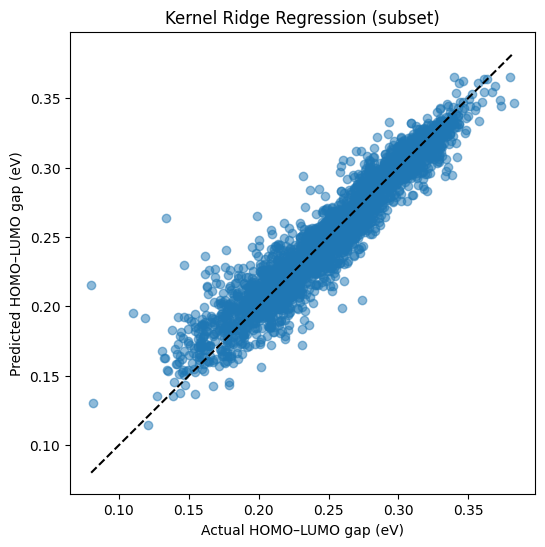

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Subsample dataset (needed for KRR because my Collab crashed otherwise)
df_krr = df_ml.sample(n=15000, random_state=42)


X = df_krr.drop(columns=["gap"]).values
y = df_krr["gap"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kernel Ridge Regression model, laplacian kernel worked better than rbf, best alpha and gamma for the highest R²
krr = KernelRidge(
    kernel="laplacian",
    alpha=1e-2,
    gamma=1e-2
)

# fit model to data
krr.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_krr = krr.predict(X_test_scaled)

# Test R²
r2_krr = r2_score(y_test, y_pred_krr)
print("KRR R² score:", r2_krr)

# Training R²
y_train_pred_krr = krr.predict(X_train_scaled)
r2_train_krr = r2_score(y_train, y_train_pred_krr)
print("KRR Training R²:", r2_train_krr)


# plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_krr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--", color="black"
)
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Kernel Ridge Regression (subset)")
plt.show()


Epoch 1/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0083 - val_loss: 7.5912e-04
Epoch 2/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.0891e-04 - val_loss: 7.1352e-04
Epoch 3/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.1932e-04 - val_loss: 4.4326e-04
Epoch 4/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.9728e-04 - val_loss: 4.3914e-04
Epoch 5/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.5082e-04 - val_loss: 4.3460e-04
Epoch 6/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.6546e-04 - val_loss: 3.5611e-04
Epoch 7/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.6612e-04 - val_loss: 3.7045e-04
Epoch 8/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0338e-04 - val_loss: 3.5162e-04
Epoch 9/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.8324e-04 - val_loss: 3.1843e-04
Epoch 10/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.6316e-04 - val_loss: 3.2450e-04
Epoch 11/300
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

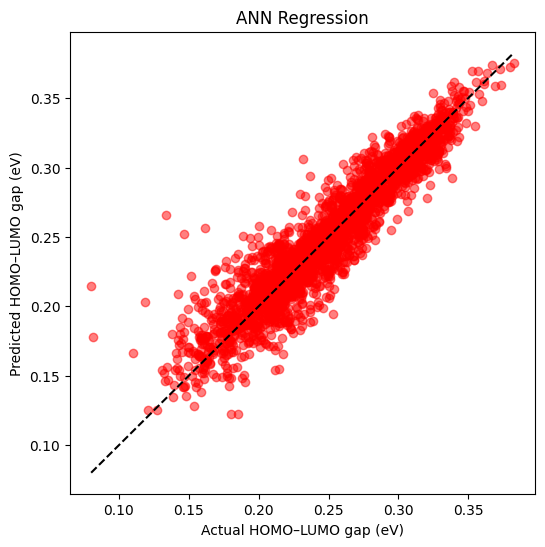

In [29]:
import tensorflow as tf
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Define simple feed-forward ANN
ann = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile model (Adam optimizer + MSE loss)
ann.compile(optimizer="adam", loss="mse")

# Train ANN
history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=16,
    verbose=1
)

# Predict on test set
y_pred_ann = ann.predict(X_test_scaled).flatten()

# Compute R² score
r2_ann = r2_score(y_test, y_pred_ann)
print("ANN R² score:", r2_ann)

# Training set predictions
y_train_pred_ann = ann.predict(X_train_scaled).flatten()
r2_train_ann = r2_score(y_train, y_train_pred_ann)
print("ANN Training R²:", r2_train_ann)


# plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann, alpha=0.5, color="red")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("ANN Regression")
plt.show()


Random Forest R² score: 0.9054203401223122
RF Training R²: 0.9847796150926446


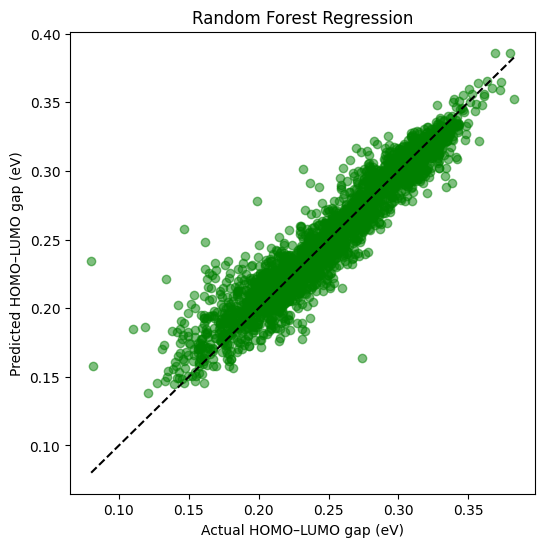

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Random Forest
rf = RandomForestRegressor(n_estimators=600, max_depth=20, min_samples_split=4, random_state=42, n_jobs=-1)

# fit model to the training data
rf.fit(X_train_scaled, y_train)

# Predict test set
y_pred_rf = rf.predict(X_test_scaled)

# Test R²
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R² score:", r2_rf)

# Training R²
y_train_pred_rf = rf.predict(X_train_scaled)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
print("RF Training R²:", r2_train_rf)

# plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "--", color="black")
plt.xlabel("Actual HOMO–LUMO gap (eV)")
plt.ylabel("Predicted HOMO–LUMO gap (eV)")
plt.title("Random Forest Regression")
plt.show()
